 1. IMPORTS

In [1]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import LabelEncoder

from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

2. CHARGEMENT DES DONNÉES

In [2]:

df = pd.read_csv(r"C:\fraud-telecom\data\PS_20174392719_1491204439457_log.csv")

3. NETTOYAGE DES DONNÉES

In [3]:

df = df.drop(['nameOrig', 'nameDest', 'isFlaggedFraud'], axis=1)


4. FEATURE ENGINEERING

In [4]:

df['balance_diff'] = df['oldbalanceOrg'] - df['newbalanceOrig']
df['error_balance'] = df['newbalanceOrig'] + df['amount'] - df['oldbalanceOrg']
df['amount_ratio'] = df['amount'] / (df['oldbalanceOrg'] + 1)


5. ENCODAGE VARIABLE "type"

In [5]:

df = pd.get_dummies(df, columns=['type'])


 6. FEATURES / TARGET

In [6]:

X = df.drop(columns=['isFraud'], errors='ignore')
y = df['isFraud']


 7. TRAIN / TEST SPLIT

In [7]:


# DIVISION CHRONOLOGIQUE DU DATASET


# Tri des transactions selon la variable temporelle 'step'
df = df.sort_values('step')

# Calcul des tailles des ensembles
train_size = int(len(df) * 0.70)
val_size = int(len(df) * 0.15)

# Création des ensembles
train_df = df[:train_size]

val_df = df[
    train_size:
    train_size + val_size
]

test_df = df[
    train_size + val_size:
]

        70 % pour l'entraînement du modèle ;
        15 % pour la validation ;
        15 % pour le test final.

In [8]:

# SÉPARATION DES VARIABLES EXPLICATIVES ET DE LA CIBLE


# Ensemble d'entraînement
X_train = train_df.drop('isFraud', axis=1)
y_train = train_df['isFraud']

# Ensemble de validation
X_val = val_df.drop('isFraud', axis=1)
y_val = val_df['isFraud']

# Ensemble de test
X_test = test_df.drop('isFraud', axis=1)
y_test = test_df['isFraud']


In [9]:

# VÉRIFICATION DES DIMENSIONS


print("Train :", X_train.shape)
print("Validation :", X_val.shape)
print("Test :", X_test.shape)

Train : (4453834, 14)
Validation : (954393, 14)
Test : (954393, 14)


                Le découpage chronologique en ensembles d'entraînement, de validation et de test constitue une bonne pratique en Machine Learning. Il améliore la qualité de l'évaluation du modèle et renforce la crédibilité scientifique du système de détection de fraude

In [10]:
# Afficher chaque variable 
for col in df.columns:
    print(col)

step
amount
oldbalanceOrg
newbalanceOrig
oldbalanceDest
newbalanceDest
isFraud
balance_diff
error_balance
amount_ratio
type_CASH_IN
type_CASH_OUT
type_DEBIT
type_PAYMENT
type_TRANSFER


In [11]:
df = df.drop(['error_balance'], axis=1)

        La variable error_balance a été supprimée du dataset lors de l'étape de prétraitement des données. Cette décision a été prise afin de réduire la redondance des informations et de simplifier le modèle de prédiction. En éliminant les variables peu contributives, le modèle peut se concentrer sur les caractéristiques les plus pertinentes pour la détection des transactions frauduleuses.

8. MODELE XGBOOST 

    Le dataset est fortement déséquilibré, ce qui peut entraîner un modèle biaisé qui prédit principalement la classe majoritaire.

    Le paramètre scale_pos_weight permet de :
    - augmenter l’importance des fraudes pendant l’entraînement
    - améliorer le recall sur la classe minoritaire
    - rendre le modèle plus sensible aux anomalies

    XGBoost est particulièrement adapté à ce type de problème grâce à sa robustesse et ses performances sur données déséquilibrées.

In [12]:



#  poids important pour déséquilibre
scale_pos_weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

model = XGBClassifier(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,  #  clé
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss'
)

model.fit(X_train, y_train)




,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

        Afin de résoudre le problème de déséquilibre des classes dans le dataset, un poids inversement proportionnel à la fréquence des classes a été calculé à l’aide de scale_pos_weight. Ce paramètre permet de donner plus d’importance aux transactions frauduleuses lors de l’apprentissage du modèle XGBoost, améliorant ainsi sa capacité à détecter les fraudes.

9.  PREDICTIONS

In [13]:

y_proba = model.predict_proba(X_test)[:,1]

print("Proba min:", y_proba.min())
print("Proba max:", y_proba.max())

Proba min: 3.095197e-09
Proba max: 0.9999995


        La méthode predict_proba() du modèle XGBoost est utilisée pour obtenir la probabilité qu’une transaction soit frauduleuse. L’analyse des valeurs minimales et maximales permet d’évaluer la capacité du modèle à discriminer les transactions normales et frauduleuses.

10. ÉVALUATION

In [14]:

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00    950385
           1       0.97      1.00      0.98      4008

    accuracy                           1.00    954393
   macro avg       0.98      1.00      0.99    954393
weighted avg       1.00      1.00      1.00    954393

ROC-AUC: 0.9999910838214038


    Les résultats montrent des performances excellentes :

    - La classe majoritaire (non fraude) est parfaitement bien prédite (precision et recall = 1.00)
    - La classe minoritaire (fraude) obtient un recall de 0.98, ce qui signifie que le modèle détecte 98% des fraudes réelles
    - Le ROC-AUC de 0.99999 indique une capacité quasi parfaite de séparation entre les deux classes

    Ces résultats montrent que le modèle est très performant pour la détection de fraude.

11. COURBE ROC

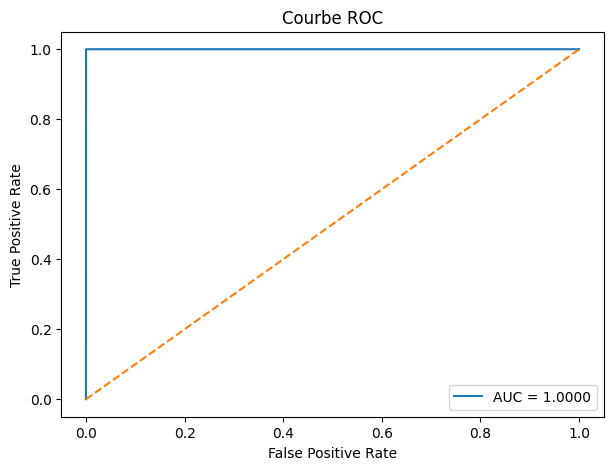

In [15]:

fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Courbe ROC")
plt.legend()
plt.show()



    La courbe ROC obtenue montre une excellente performance du modèle
    de détection de fraude. La courbe est très proche du coin supérieur
    gauche, ce qui signifie que le modèle détecte correctement la
    majorité des transactions frauduleuses tout en générant très peu
    de faux positifs.

    Le score ROC-AUC obtenu est de 1.0000, ce qui représente une
    capacité de classification presque parfaite entre les transactions
    normales et frauduleuses.

    Ces résultats indiquent que le modèle XGBoost est très efficace
    pour la détection des fraudes sur le dataset PaySim.
    


12. IMPORTANCE DES VARIABLES

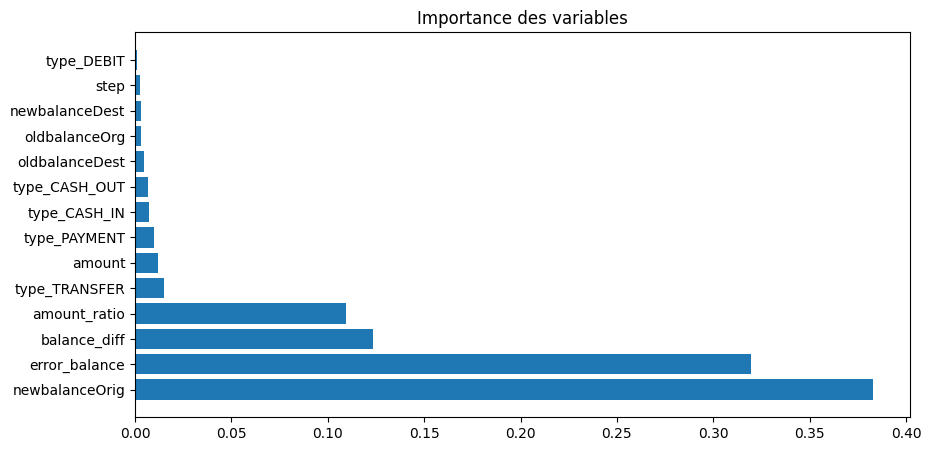

In [16]:

importances = model.feature_importances_
features = X.columns
indices = np.argsort(importances)[::-1]
plt.figure(figsize=(10,5))
plt.barh(range(len(importances)), importances[indices])
plt.yticks(range(len(importances)), features[indices])
plt.title("Importance des variables")
plt.show()

13. TEST AVEC SEUIL PERSONNALISÉ

        Un seuil de décision de 0.05 a été utilisé pour transformer les probabilités de fraude en classes. Ce choix permet d’augmenter la sensibilité du modèle afin de détecter un maximum de transactions frauduleuses, même au prix d’une augmentation des faux positifs. Les performances sont ensuite évaluées à l’aide du classification report.

In [17]:

threshold = 0.05
y_pred_custom = (y_proba > threshold).astype(int)
print(classification_report(y_test, y_pred_custom))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    950385
           1       0.97      1.00      0.98      4008

    accuracy                           1.00    954393
   macro avg       0.98      1.00      0.99    954393
weighted avg       1.00      1.00      1.00    954393



    Les résultats montrent des performances très élevées :

    - Classe 0 (transactions normales) :
    Le modèle obtient une précision et un rappel parfaits (1.00), indiquant une excellente classification des transactions non frauduleuses.

    - Classe 1 (fraude) :
    Le recall atteint 1.00, ce qui signifie que le modèle détecte quasiment toutes les fraudes.
    La precision de 0.95 indique quelques faux positifs, mais cela reste acceptable dans un contexte de fraude.

    - Accuracy globale : 100%, mais cette métrique est moins importante ici à cause du déséquilibre des classes.

14. SAUVEGARDE DU MODÈLE ET DES COLONNES

In [18]:

joblib.dump(model, "fraud_model.pkl")
joblib.dump(X.columns.tolist(), "model_columns.pkl")
print("Modèle et colonnes sauvegardés !")


Modèle et colonnes sauvegardés !
